# Complete PyTorch Learning Guide

This notebook combines all PyTorch basics tutorials:
1. Tensors
2. Datasets & DataLoaders
3. Transforms
4. Building Neural Networks
5. Automatic Differentiation (Autograd)
6. Optimization
7. Saving and Loading Models

---
# Part 1: PyTorch Basics - Tensors
---

In [6]:
import torch
import numpy as np

## Creating Tensors

We can create tensors in multiple ways:
- Directly from Python data
- From NumPy arrays
- Using built-in tensor creation functions like `rand`, `ones`, `zeros`

In [7]:
# From data
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)
print("Tensor from data:\n", x_data)

# From NumPy
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print("Tensor from NumPy array:\n", x_np)

# With shapes
x_rand = torch.rand((2, 3))
x_ones = torch.ones((2, 3))
x_zeros = torch.zeros((2, 3))
print("Random tensor:\n", x_rand)
print("Ones tensor:\n", x_ones)
print("Zeros tensor:\n", x_zeros)

Tensor from data:
 tensor([[1, 2],
        [3, 4]])
Tensor from NumPy array:
 tensor([[1, 2],
        [3, 4]], dtype=torch.int32)
Random tensor:
 tensor([[0.8295, 0.8254, 0.6946],
        [0.2347, 0.1326, 0.6520]])
Ones tensor:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
Zeros tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


## Tensor Attributes

Every PyTorch tensor has several important attributes:
- **Shape**: number of rows and columns
- **Datatype**: type of data stored (float, int, etc.)
- **Device**: whether the tensor is on CPU or GPU

In [8]:
tensor = torch.rand(3, 4)
print("Tensor:\n", tensor)
print("Shape:", tensor.shape)
print("Datatype:", tensor.dtype)
print("Device:", tensor.device)

Tensor:
 tensor([[0.2017, 0.1262, 0.4778, 0.4276],
        [0.3017, 0.1725, 0.5057, 0.3942],
        [0.8542, 0.6126, 0.3620, 0.7769]])
Shape: torch.Size([3, 4])
Datatype: torch.float32
Device: cpu


## Basic Operations

Perform many mathematical operations on tensors:
- Indexing and slicing
- Concatenation
- Matrix multiplication
- Element-wise operations
- Aggregations like sum

In [9]:
tensor = torch.ones(4, 4)
print("Original Tensor:\n", tensor)

# Indexing
print("First row:", tensor[0])
print("First column:", tensor[:, 0])

# Concatenate
print("Concatenated (row-wise):\n", torch.cat([tensor, tensor], dim=0))

# Matrix multiplication
print("Matrix multiplication result:\n", tensor @ tensor.T)

# Element-wise multiplication
print("Element-wise multiplication:\n", tensor * tensor)

# Sum
print("Sum of all elements:", tensor.sum().item())

Original Tensor:
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Concatenated (row-wise):
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
Matrix multiplication result:
 tensor([[4., 4., 4., 4.],
        [4., 4., 4., 4.],
        [4., 4., 4., 4.],
        [4., 4., 4., 4.]])
Element-wise multiplication:
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
Sum of all elements: 16.0


## NumPy ↔ PyTorch Bridge

PyTorch tensors and NumPy arrays can share memory, which means changes in one will reflect in the other.

In [10]:
# Tensor to NumPy
t = torch.ones(5)
n = t.numpy()
print("Before:", n)

t.add_(1)  # in-place operation on tensor
print("After modifying tensor:", n)

# NumPy to Tensor
n = np.ones(5)
t = torch.from_numpy(n)
np.add(n, 1, out=n)
print("Tensor updated too:", t)

Before: [1. 1. 1. 1. 1.]
After modifying tensor: [2. 2. 2. 2. 2.]
Tensor updated too: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


---
# Part 2: PyTorch Basics - Datasets & DataLoaders
---

PyTorch provides two primitives:
- `torch.utils.data.Dataset`: stores samples and labels
- `torch.utils.data.DataLoader`: wraps an iterable around the Dataset for easy minibatch loading, shuffling, and multiprocessing

Domain libraries like TorchVision, TorchText, and TorchAudio provide pre-loaded datasets (like FashionMNIST for images).

## Loading a Dataset

We can load the [FashionMNIST](https://pytorch.org/vision/stable/datasets.html#fashion-mnist) dataset easily using TorchVision:

- `root`: path to download/store data
- `train`: whether to load training or test split
- `download=True`: fetch data from the internet if not locally available
- `transform`: transformations to apply on the image data
- `target_transform`: transformations to apply on the labels

In [6]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Iterating and Visualizing the Dataset

Datasets can be indexed directly with `dataset[index]`. Below, we display random samples using Matplotlib.

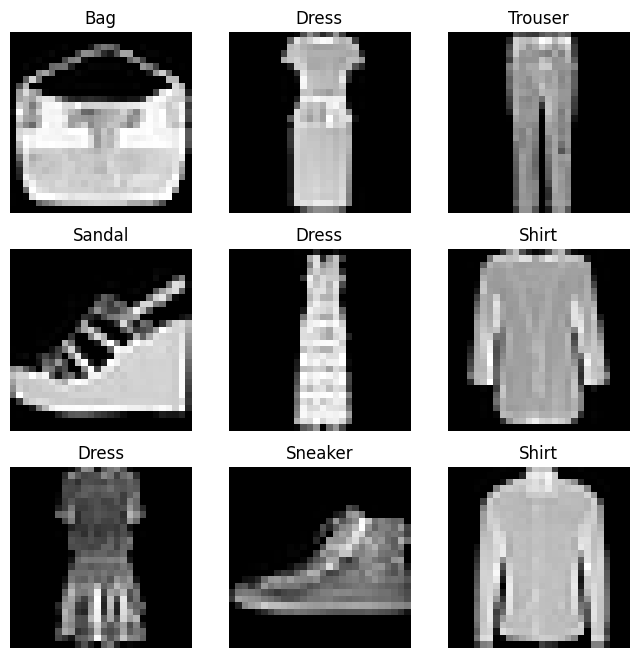

In [7]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

## Creating a Custom Dataset for Your Own Data

To work with your own datasets, subclass `Dataset` and override three methods:
- `__init__`: initialize file paths or annotations
- `__len__`: return the number of samples
- `__getitem__`: retrieve an image + label pair by index

In [8]:
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

## Preparing Data with DataLoader

The Dataset only fetches **one sample at a time**. The DataLoader wraps it to provide:
- **Batching** (minibatches)
- **Shuffling** (data is reshuffled each epoch)
- **Parallel loading** with the `num_workers` argument

In [9]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

## Iterating through DataLoader

Each iteration yields a batch of images and labels.

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


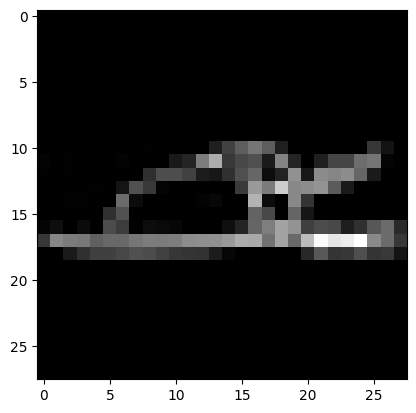

Label: tensor([5, 4, 7, 2, 0, 1, 0, 5, 7, 7, 6, 1, 2, 5, 8, 4, 1, 6, 0, 1, 7, 2, 0, 5,
        9, 0, 7, 4, 3, 6, 7, 0, 8, 3, 2, 8, 3, 5, 7, 1, 8, 4, 4, 0, 1, 9, 4, 8,
        2, 7, 1, 7, 7, 6, 6, 7, 4, 8, 4, 5, 1, 1, 0, 0])


In [10]:
# Grab a batch of training data
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
label = train_labels
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

---
# Part 3: PyTorch Basics - Transforms
---

In [1]:

import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

## Why Do We Need Transforms?

Raw data (like images and labels) is not always in the format needed for training models. Transforms allow us to:
- Convert raw image data into tensors
- Normalize values for training
- Convert labels into a usable format (e.g., one-hot encoding)

TorchVision datasets support two arguments:
- **`transform`**: modifies the input features (e.g., images)
- **`target_transform`**: modifies the labels (targets)

## Applying Transforms to a Dataset

Let's apply transforms when loading the FashionMNIST dataset:
- `ToTensor()` will convert PIL images into tensors scaled between `0` and `1`.
- `Lambda` will convert labels (integers) into one-hot encoded vectors.

In [2]:
ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

print("Number of training samples:", len(ds))

Number of training samples: 60000


##  The `ToTensor()` Transform

- Converts a **PIL Image** or **NumPy array** into a **FloatTensor**.
- Normalizes pixel values to range `[0., 1.]`.

Example:
- A grayscale image with pixel values `[0, 255]` gets scaled to `[0.0, 1.0]`.

##  Using `Lambda` Transforms

`Lambda` allows us to define custom transformations. Example use case:
- Turn integer labels into **one-hot encoded vectors**.
- Steps:
  1. Create a zero tensor of size equal to the number of classes.
  2. Use the [`scatter_`] method to set the label index to `1`.


In [3]:
target_transform = Lambda(lambda y: torch.zeros(10, dtype=torch.float)
                                        .scatter_(dim=0, index=torch.tensor(y), value=1))

# Example: convert label 3 into one-hot encoded tensor
print(target_transform(3))

tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])


---
# Part 4: PyTorch Basics - Building Neural Networks
---

In [25]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## Get Device for Training

We want to train on hardware accelerators like CUDA/MPS/XPU if available, otherwise on CPU.

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cpu device


## Define the Network Class

Subclass `nn.Module`. Define layers in `__init__`, and the forward pass in `forward`.

In [27]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

## Instantiate and Print Model

In [28]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


## Forward Pass Example

Passing an input through the model executes `forward`.
Predicted class probabilities are obtained with `Softmax`.

In [29]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([7])


---

# Model Layers Exploration

We’ll examine how inputs are transformed through different layers.

In [30]:
input_image = torch.rand(3, 28, 28)
print(input_image.size())

torch.Size([3, 28, 28])


### nn.Flatten

Converts 2D images (28x28) into a flat vector (784).

In [31]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


### nn.Linear

Applies a linear transformation using learned weights and biases.

In [32]:
layer1 = nn.Linear(28*28, 20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


### nn.ReLU

Applies nonlinearity after linear layers to allow learning complex relationships.

In [33]:
print("Before ReLU:", hidden1[:2])
hidden1 = nn.ReLU()(hidden1)
print("After ReLU:", hidden1[:2])

Before ReLU: tensor([[-0.1885, -0.2230,  0.2097, -0.1096,  0.4980, -0.1238,  0.4080,  0.0542,
          0.0061,  0.2525,  0.0825,  0.1495,  0.1903, -0.2306,  0.0803, -0.0955,
          0.1478, -0.2301,  0.0805, -0.0721],
        [ 0.1496, -0.3489,  0.2172, -0.0372,  0.2364,  0.1059,  0.0540, -0.0450,
          0.1829,  0.1053, -0.0709,  0.4797,  0.2287,  0.0276, -0.1399,  0.1991,
         -0.2350, -0.2555,  0.1133, -0.0264]], grad_fn=<SliceBackward0>)
After ReLU: tensor([[0.0000, 0.0000, 0.2097, 0.0000, 0.4980, 0.0000, 0.4080, 0.0542, 0.0061,
         0.2525, 0.0825, 0.1495, 0.1903, 0.0000, 0.0803, 0.0000, 0.1478, 0.0000,
         0.0805, 0.0000],
        [0.1496, 0.0000, 0.2172, 0.0000, 0.2364, 0.1059, 0.0540, 0.0000, 0.1829,
         0.1053, 0.0000, 0.4797, 0.2287, 0.0276, 0.0000, 0.1991, 0.0000, 0.0000,
         0.1133, 0.0000]], grad_fn=<SliceBackward0>)


### nn.Sequential

Combines layers in order into a container.

In [34]:
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
logits = seq_modules(input_image)
print(logits.size())

torch.Size([3, 10])


### nn.Softmax

Turns raw logits into probabilities that sum to 1.

In [35]:
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)
print(pred_probab[:2])

tensor([[0.0965, 0.1177, 0.1064, 0.1019, 0.1010, 0.0985, 0.1103, 0.0872, 0.0831,
         0.0974],
        [0.0876, 0.1189, 0.1236, 0.0996, 0.1048, 0.0970, 0.1100, 0.0791, 0.0869,
         0.0924]], grad_fn=<SliceBackward0>)


## Inspecting Model Parameters

Each layer has trainable weights and biases stored as parameters.

In [36]:
print("Model structure:", model, "\n")
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values: {param[:2]}")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
) 

Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values: tensor([[-0.0237, -0.0271,  0.0201,  ..., -0.0347,  0.0134, -0.0064],
        [-0.0153, -0.0168, -0.0107,  ...,  0.0192, -0.0086,  0.0151]],
       grad_fn=<SliceBackward0>)
Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values: tensor([-0.0210,  0.0207], grad_fn=<SliceBackward0>)
Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values: tensor([[ 0.0147, -0.0196,  0.0023,  ...,  0.0122,  0.0110, -0.0251],
        [ 0.0067, -0.0071, -0.0278,  ...,  0.0298, -0.0355, -0.0155]],
       grad_fn=<SliceBackward0>)
Layer: linear_relu_stack.2.bias | Size: tor

---
# Part 5: PyTorch Basics - Automatic Differentiation (Autograd)
---

In [7]:
import torch

x = torch.ones(5)              # input tensor
y = torch.zeros(3)             # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w) + b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

## Tensors, Functions, and Computational Graphs

This code defines the following **computational graph**:

![Computational Graph](https://pytorch.org/tutorials/_static/img/basics/comp-graph.png)

`w` and `b` are **parameters** we want to optimize. We enable autograd by setting `requires_grad=True`.

Every function applied to tensors creates a `Function` object in the graph. Each tensor's `.grad_fn` stores the function that created it.

In [8]:
print(f"Gradient function for z: {z.grad_fn}")
print(f"Gradient function for loss: {loss.grad_fn}")

Gradient function for z: <AddBackward0 object at 0x000001E03DF0FA60>
Gradient function for loss: <BinaryCrossEntropyWithLogitsBackward0 object at 0x000001E03BE3C7C0>


## Computing Gradients

To optimize network parameters, compute derivatives of loss with respect to them using `backward()`.

In [9]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.3228, 0.3215, 0.1390],
        [0.3228, 0.3215, 0.1390],
        [0.3228, 0.3215, 0.1390],
        [0.3228, 0.3215, 0.1390],
        [0.3228, 0.3215, 0.1390]])
tensor([0.3228, 0.3215, 0.1390])


> **Note:**
- Only **leaf nodes** with `requires_grad=True` have gradients stored.
- For efficiency, a computational graph is freed after `.backward()`. Use `retain_graph=True` if you need multiple backward passes.

## Disabling Gradient Tracking

Once trained, we often want to only do forward passes. Disable gradient tracking for faster computation using `torch.no_grad()`.

In [10]:
z = torch.matmul(x, w) + b
print(z.requires_grad)

with torch.no_grad():
    z = torch.matmul(x, w) + b
print(z.requires_grad)

True
False


Another way is to use `.detach()` to get a tensor that shares the same values but does not require gradients.

In [11]:
z = torch.matmul(x, w) + b
z_det = z.detach()
print(z_det.requires_grad)

False


**Why disable gradients?**
- To freeze parameters during evaluation.
- To speed up forward computations.

In [12]:
inp = torch.eye(4, 5, requires_grad=True)
out = (inp + 1).pow(2).t()

out.backward(torch.ones_like(out), retain_graph=True)
print("First call\n", inp.grad)

out.backward(torch.ones_like(out), retain_graph=True)
print("\nSecond call (accumulated)\n", inp.grad)

inp.grad.zero_()
out.backward(torch.ones_like(out), retain_graph=True)
print("\nAfter zeroing gradients\n", inp.grad)

First call
 tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.]])

Second call (accumulated)
 tensor([[8., 4., 4., 4., 4.],
        [4., 8., 4., 4., 4.],
        [4., 4., 8., 4., 4.],
        [4., 4., 4., 8., 4.]])

After zeroing gradients
 tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.]])


---
# Part 6: PyTorch Basics - Optimization
---

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# Dataset
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

# Simple Neural Network
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

## Hyperparameters

Adjustable parameters that influence training:
- **Epochs**: # of times to iterate over dataset
- **Batch Size**: samples per weight update
- **Learning Rate**: step-size per update

In [2]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

## Loss Function

Loss measures error between predictions and ground-truth labels. Here we use `CrossEntropyLoss` (good for classification).

In [3]:
loss_fn = nn.CrossEntropyLoss()

## Optimizer

Optimization algorithms adjust parameters using gradients. PyTorch has several optimizers (SGD, Adam, RMSProp, etc.).

In [4]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Inside each training step:
1. `optimizer.zero_grad()` — clear previously accumulated gradients
2. `loss.backward()` — backpropagate loss
3. `optimizer.step()` — update parameters

## Training and Test Loops

In [5]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Prediction & loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss_val, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

## Full Training Run

In [6]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Training complete!")

Epoch 1
-------------------------------
loss: 2.297820  [   64/60000]
loss: 2.289397  [ 6464/60000]
loss: 2.268764  [12864/60000]
loss: 2.263272  [19264/60000]
loss: 2.244152  [25664/60000]
loss: 2.211899  [32064/60000]
loss: 2.221232  [38464/60000]
loss: 2.188820  [44864/60000]
loss: 2.185863  [51264/60000]
loss: 2.138820  [57664/60000]
Test Error: 
 Accuracy: 43.8%, Avg loss: 2.147606 

Epoch 2
-------------------------------
loss: 2.163435  [   64/60000]
loss: 2.151595  [ 6464/60000]
loss: 2.090426  [12864/60000]
loss: 2.106952  [19264/60000]
loss: 2.047055  [25664/60000]
loss: 1.989485  [32064/60000]
loss: 2.018526  [38464/60000]
loss: 1.941776  [44864/60000]
loss: 1.949016  [51264/60000]
loss: 1.849228  [57664/60000]
Test Error: 
 Accuracy: 57.9%, Avg loss: 1.870097 

Epoch 3
-------------------------------
loss: 1.910527  [   64/60000]
loss: 1.876909  [ 6464/60000]
loss: 1.758325  [12864/60000]
loss: 1.797725  [19264/60000]
loss: 1.682457  [25664/60000]
loss: 1.640916  [32064/600

---
# Part 7: PyTorch Basics - Saving and Loading Models
---

In [1]:
import torch
import torchvision.models as models

## Saving and Loading Model Weights

PyTorch models store learned parameters in a dictionary called `state_dict`. 
We can save it using `torch.save()`.

In [ ]:
model = models.vgg16(weights="IMAGENET1K_V1")
torch.save(model.state_dict(), "model_weights.pth")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\SARTH/.cache\torch\hub\checkpoints\vgg16-397923af.pth


 54%|█████▍    | 288M/528M [01:43<01:20, 3.12MB/s] 

To load model weights, first create an untrained instance of the same model, 
then call `load_state_dict()`. 

`weights_only=True` to restrict pickle execution to just loading parameters, which is considered best practice.

In [ ]:
model = models.vgg16()  # untrained model
model.load_state_dict(torch.load("model_weights.pth", weights_only=True))
model.eval()

## Saving and Loading Models with Architecture

In [ ]:
torch.save(model, "model.pth")

In [ ]:
model = torch.load("model.pth", weights_only=False)
model.eval()